In [ ]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgr_df = pickle.load(open('C:/Users/ejeme/Documents/python_repos/SGR/CIFAR10/sgr_set','rb'))
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-10 dataset

(30000, 3)


,y_true,y_pred,SR
2308,9.0,9.0,0.289903
22404,0.0,0.0,0.141633
23397,9.0,9.0,0.320855
25058,1.0,1.0,0.284781
2664,1.0,1.0,0.271898


## <font color = 'yellow'> SGR with __0/1 loss__ for multiclass classification task

In [3]:
train_set = sgr_df.iloc[:15000]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[15000:]

In [4]:
delta = 0.001
desired_risks=[i/1000 for i in integers_log_spacing(5,300)]

In [5]:
results = SGR_at_risks(train_set, test_set, k=int(np.log2(train_set.shape[0])), 
                       delta=delta, desired_risks=desired_risks, union = False)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.005,0.004479,0.000486,0.137133,0.003530,0.132200
1,0.006,0.005198,0.000928,0.143733,0.003369,0.138533
2,0.007,0.006687,0.001812,0.147133,0.003311,0.140933
3,0.008,0.008309,0.003309,0.181333,0.003880,0.171800
4,0.009,0.009171,0.004312,0.216467,0.004507,0.207067
5,0.010,0.009772,0.005224,0.268000,0.007388,0.252667
6,0.011,0.011138,0.006556,0.305067,0.007590,0.289867
7,0.012,0.012185,0.007445,0.313400,0.007856,0.297000
8,0.014,0.013878,0.009159,0.363933,0.010068,0.344333
9,0.015,0.015129,0.010339,0.386867,0.010547,0.366600


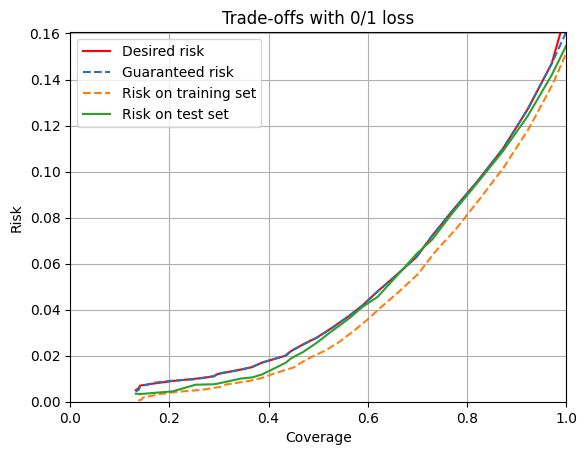

In [6]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.title('Trade-offs with 0/1 loss')
plt.ylim(0,max(results.risk_bound))
plt.xlim(0,1)
plt.legend()
plt.grid()
plt.show()

__Comment__ : 
1) risk coverage curve is convex here => the marginal cost of coverage increases
2) (1- Risk reached at 100% coverage) = classifier accuracy ~84% here